# BV Algo 


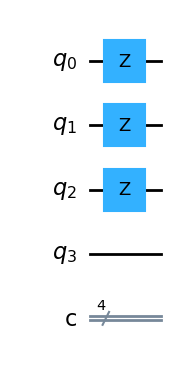

0111


In [21]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

"""Takes string input of bits and return oracle that contains the secret key"""
def SecretMaker(Input):
    n = len(Input)
    qc = QuantumCircuit(n,n)
    for i, qubit in enumerate(Input):
        if qubit == "1":
            qc.z(i)
    return qc 


def FindSecret(circuit):
    n = circuit.num_qubits 
    qc = QuantumCircuit(n,n)
    for i in range(n): 
        qc.h(i)
    qc = qc.compose(circuit)
    for i in range(n): 
        qc.h(i)
    qc.measure(range(0,n), range(0,n))
    result = AerSimulator().run(qc, shots=100, memory=True).result()
    return result.get_memory()[0]


qc = SecretMaker("0111").reverse_bits()
display(qc.draw('mpl'))
secret = FindSecret(qc)
print(secret)


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def bernstein_vazirani_algorithm(s: str):
    """
    Implements the Bernstein-Vazirani algorithm.
    
    Parameters:
    s (str): The hidden bit string.
    
    Returns:
    dict: The measurement results.
    """
    n = len(s)
    
    # Create quantum circuit with n qubits + 1 auxiliary qubit
    qc = QuantumCircuit(n + 1, n)
    
    # Initialize last qubit in |1⟩ state
    qc.x(n)
    
    # Apply Hadamard gates to all qubits
    qc.h(range(n + 1))
    
    # Oracle: Apply CNOT gates controlled on 's'
    for i, bit in enumerate(s):
        if bit == '1':
            qc.cx(i, n)  # CNOT from qubit i to the auxiliary qubit
    
    # Apply Hadamard gates again to first n qubits
    qc.h(range(n))
    
    # Measure the first n qubits
    qc.measure(range(n), range(n))
    
    # Simulate the circuit
    result = AerSimulator().run(qc, shots=100, memory=True).result()
    return result.get_memory()[0]
    

# Example: Run BV algorithm for s = '1011'
s = "1011"
output = bernstein_vazirani_algorithm(s)
print(output)


1101
